In [67]:
import os
from datetime import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from alpaca.data.historical import StockHistoricalDataClient
from alpaca.data.requests import StockBarsRequest
from alpaca.data.timeframe import TimeFrame, TimeFrameUnit
import statsmodels.api as sm


In [68]:
# === CONFIG ===
ALPACA_API_KEY = ("---------")
ALPACA_SECRET_KEY = ("-------------")

SYMBOL = "TQQQ"       # switch to "TQQQ" later if you want
START = datetime(2016, 1, 1)
END   = datetime(2025, 12, 1)   # or whatever "recent years" you want

START_CAPITAL = 10_000
RISK_PCT = 0.01          # 1% per trade
MAX_LEVERAGE = 4.0
COMMISSION_PER_SHARE = 0.0005   # per side

client = StockHistoricalDataClient(ALPACA_API_KEY, ALPACA_SECRET_KEY)
data_client = client


In [69]:
def get_5min_bars(symbol, start, end):
    """Download 5-minute bars from Alpaca and return a tz-aware DataFrame."""
    req = StockBarsRequest(
        symbol_or_symbols=symbol,
        timeframe=TimeFrame(5, TimeFrameUnit.Minute),
        start=start,
        end=end,
    )
    bars = client.get_stock_bars(req)
    df = bars.df  # MultiIndex: (symbol, timestamp)

    # If you requested a single symbol, you can drop the symbol level
    df = df.reset_index()
    df = df[df["symbol"] == symbol].set_index("timestamp").sort_index()

    # Ensure timezone is NY (Alpaca gives UTC)
    df.index = df.index.tz_convert("America/New_York")

    # Restrict to regular hours 9:30-16:00
    df = df.between_time("09:30", "16:00")

    return df[["open", "high", "low", "close", "volume"]]


In [70]:
def get_daily_bars(symbol, start, end):
    req = StockBarsRequest(
        symbol_or_symbols=symbol,
        timeframe=TimeFrame.Day,
        start=start,
        end=end,
    )
    bars = client.get_stock_bars(req)
    df = bars.df.reset_index()
    df = df[df["symbol"] == symbol].set_index("timestamp").sort_index()
    df.index = df.index.tz_convert("America/New_York")
    return df[["open", "high", "low", "close", "volume"]]


In [71]:
bars_5m = get_5min_bars(SYMBOL, START, END)
daily_qqq = get_daily_bars("QQQ", START, END)


In [72]:
def backtest_orb_5m(
    bars_5m,
    start_capital=START_CAPITAL,
    risk_pct=RISK_PCT,
    max_leverage=MAX_LEVERAGE,
    commission_per_share=COMMISSION_PER_SHARE,
    profit_mult=10.0,
):
    """
    Run the ORB strategy described in the paper on 5-minute bars.
    Returns (equity_curve, daily_returns, trades_df).
    """
    # Group by date (NY time)
    days = list(bars_5m.groupby(bars_5m.index.date))

    equity = start_capital
    equity_curve = []
    daily_returns = []
    dates = []
    trades = []

    for date, df_day in days:
        df_day = df_day.sort_index()

        # Need at least 2 bars
        if len(df_day) < 2:
            continue

        # First and second 5-minute candles
        first = df_day.iloc[0]
        second = df_day.iloc[1]

        # Doji: skip
        if np.isclose(first["close"], first["open"]):
            equity_curve.append(equity)
            daily_returns.append(0.0)
            dates.append(pd.Timestamp(date))
            continue

        direction = 1 if first["close"] > first["open"] else -1  # +1 long, -1 short
        entry_price = second["open"]

        if direction == 1:
            stop_price = first["low"]
            R = entry_price - stop_price
        else:
            stop_price = first["high"]
            R = stop_price - entry_price

        if R <= 0:
            # Something pathological, skip
            equity_curve.append(equity)
            daily_returns.append(0.0)
            dates.append(pd.Timestamp(date))
            continue

        # Position sizing
        account_risk_dollars = equity * risk_pct
        shares_risk = account_risk_dollars / R
        shares_leverage_cap = (equity * max_leverage) / entry_price
        shares = int(min(shares_risk, shares_leverage_cap))

        if shares <= 0:
            equity_curve.append(equity)
            daily_returns.append(0.0)
            dates.append(pd.Timestamp(date))
            continue

        # Simulate intraday path from second bar onwards
        position_sign = direction
        exit_price = None
        reason = "EOD"
        entry_time = df_day.index[1]

        # Profit target
        if direction == 1:
            target_price = entry_price + profit_mult * R
        else:
            target_price = entry_price - profit_mult * R

        for ts, bar in df_day.iloc[1:].iterrows():
            high = bar["high"]
            low = bar["low"]

            if direction == 1:
                # Assume worst-case: price can hit stop before target inside bar
                if low <= stop_price:
                    exit_price = stop_price
                    reason = "STOP"
                    exit_time = ts
                    break
                if high >= target_price:
                    exit_price = target_price
                    reason = "TARGET"
                    exit_time = ts
                    break
            else:
                if high >= stop_price:
                    exit_price = stop_price
                    reason = "STOP"
                    exit_time = ts
                    break
                if low <= target_price:
                    exit_price = target_price
                    reason = "TARGET"
                    exit_time = ts
                    break

        if exit_price is None:
            # EOD exit at last close
            last_bar = df_day.iloc[-1]
            exit_price = last_bar["close"]
            exit_time = df_day.index[-1]

        # PnL
        pnl_per_share = (exit_price - entry_price) * position_sign
        gross_pnl = pnl_per_share * shares
        commission = commission_per_share * shares * 2  # entry + exit
        net_pnl = gross_pnl - commission

        equity_start_day = equity
        equity += net_pnl
        day_ret = net_pnl / equity_start_day

        equity_curve.append(equity)
        daily_returns.append(day_ret)
        dates.append(pd.Timestamp(date))

        trades.append(
            {
                "date": date,
                "entry_time": entry_time,
                "exit_time": exit_time,
                "direction": "LONG" if direction == 1 else "SHORT",
                "entry": entry_price,
                "exit": exit_price,
                "stop": stop_price,
                "target": target_price,
                "shares": shares,
                "gross_pnl": gross_pnl,
                "net_pnl": net_pnl,
                "day_return": day_ret,
                "reason": reason,
            }
        )

    equity_series = pd.Series(equity_curve, index=pd.to_datetime(dates))
    ret_series = pd.Series(daily_returns, index=pd.to_datetime(dates))
    trades_df = pd.DataFrame(trades)

    return equity_series, ret_series, trades_df


In [73]:
orb_equity, orb_daily_ret, trades = backtest_orb_5m(bars_5m)
trades.head()


,date,entry_time,exit_time,direction,entry,exit,stop,target,shares,gross_pnl,net_pnl,day_return,reason
0,2016-01-04,2016-01-04 09:35:00-05:00,2016-01-04 15:55:00-05:00,SHORT,105.7820,106.73,106.73,96.3020,105,-99.5400,-99.6450,-0.009965,STOP
1,2016-01-05,2016-01-05 09:35:00-05:00,2016-01-05 16:00:00-05:00,SHORT,108.0800,106.50,108.93,99.5800,116,183.2800,183.1640,0.018501,EOD
2,2016-01-06,2016-01-06 09:35:00-05:00,2016-01-06 16:00:00-05:00,LONG,101.2300,103.90,100.84,105.1300,258,688.8600,688.6020,0.068290,EOD
3,2016-01-07,2016-01-07 09:35:00-05:00,2016-01-07 09:35:00-05:00,SHORT,96.2708,96.79,96.79,91.0788,207,-107.4744,-107.6814,-0.009996,STOP
4,2016-01-08,2016-01-08 09:35:00-05:00,2016-01-08 10:10:00-05:00,LONG,96.7699,95.38,95.38,110.6689,76,-105.6324,-105.7084,-0.009912,STOP


In [74]:
# === New Benchmark: Buy & Hold QQQ from the same 5-min data ===

# Build a daily close series from the 5-min bars
daily_close = (
    bars_5m["close"]
    .groupby(bars_5m.index.date)
    .last()
)
daily_close.index = pd.to_datetime(daily_close.index)  # tz-naive dates

# Buy & Hold equity curve and returns
bh_rets = daily_close.pct_change().dropna()
bh_equity = (1 + bh_rets).cumprod() * START_CAPITAL

print("ORB starts:", orb_equity.index.min())
print("BH  starts:", bh_equity.index.min())

ORB starts: 2016-01-04 00:00:00
BH  starts: 2016-01-05 00:00:00


In [75]:
def performance_stats(daily_rets, equity_curve=None, ann_factor=252):
    """
    Compute performance stats with keys matching the older notebook format:
    'CAGR', 'Annual Vol', 'Sharpe', 'MaxDD', 'Total Return', 'NumDays'.
    """
    rets = daily_rets.dropna()
    if rets.empty:
        return {
            "CAGR": np.nan,
            "Annual Vol": np.nan,
            "Sharpe": np.nan,
            "MaxDD": np.nan,
            "Total Return": np.nan,
            "NumDays": 0,
        }

    # Total return over the sample (geometric)
    total_ret = (1 + rets).prod() - 1
    n = len(rets)

    # CAGR (annualized geometric return)
    cagr = (1 + total_ret) ** (ann_factor / n) - 1

    # Annualized volatility
    vol = rets.std()
    ann_vol = vol * np.sqrt(ann_factor) if vol > 0 else np.nan

    # Sharpe ratio (rf = 0)
    if ann_vol > 0 and not np.isnan(ann_vol):
        sharpe = cagr / ann_vol
    else:
        sharpe = np.nan

    # Max drawdown from equity curve if provided
    max_dd = np.nan
    if equity_curve is not None and len(equity_curve) > 1:
        ec = equity_curve.loc[rets.index]
        running_max = ec.cummax()
        dd = ec / running_max - 1
        max_dd = dd.min()

    return {
        "CAGR": cagr,
        "Annual Vol": ann_vol,
        "Sharpe": sharpe,
        "MaxDD": max_dd,
        "Total Return": total_ret,
        "NumDays": n,
    }

In [76]:
# === Align ORB and BH for stats & regression ===

orb_eq = orb_equity.copy()   # ORB equity from backtest
bh_eq  = bh_equity.copy()    # BH equity from 5-min data

# Indices are already tz-naive, so intersection is straightforward
common_idx = orb_eq.index.intersection(bh_eq.index)

orb_equity_aligned = orb_eq.loc[common_idx]
bh_equity_aligned  = bh_eq.loc[common_idx]

orb_rets = orb_equity_aligned.pct_change().dropna()
bh_rets  = bh_equity_aligned.pct_change().dropna()

orb_stats = performance_stats(orb_rets, orb_equity_aligned)
bh_stats  = performance_stats(bh_rets,  bh_equity_aligned)

print("ORB stats:", orb_stats)
print("BH stats:", bh_stats)


ORB stats: {'CAGR': np.float64(0.3650080951310173), 'Annual Vol': np.float64(0.3799460741836017), 'Sharpe': np.float64(0.9606839494665605), 'MaxDD': -0.37549776672306423, 'Total Return': np.float64(20.640373018586097), 'NumDays': 2490}
BH stats: {'CAGR': np.float64(-0.06548458152625325), 'Annual Vol': np.float64(0.7665163659395077), 'Sharpe': np.float64(-0.08543141990972336), 'MaxDD': -0.918799113439452, 'Total Return': np.float64(-0.48788638497653003), 'NumDays': 2490}


In [77]:
# === Align ORB and BH for stats & regression (pretty summary) ===

orb_eq = orb_equity.copy()   # ORB equity from backtest
bh_eq  = bh_equity.copy()    # BH equity from 5-min data

# Intersection of dates
common_idx = orb_eq.index.intersection(bh_eq.index)

orb_equity_aligned = orb_eq.loc[common_idx]
bh_equity_aligned  = bh_eq.loc[common_idx]

orb_rets = orb_equity_aligned.pct_change().dropna()
bh_rets  = bh_equity_aligned.pct_change().dropna()

orb_stats = performance_stats(orb_rets, orb_equity_aligned)
bh_stats  = performance_stats(bh_rets,  bh_equity_aligned)

# ---- Pretty table ----
def to_pct(x):
    return float(x) * 100 if pd.notnull(x) else np.nan

summary_df = pd.DataFrame(
    {
        "CAGR %":        [to_pct(orb_stats["CAGR"]),        to_pct(bh_stats["CAGR"])],
        "Ann. Vol %":    [to_pct(orb_stats["Annual Vol"]), to_pct(bh_stats["Annual Vol"])],
        "Sharpe":        [orb_stats["Sharpe"],             bh_stats["Sharpe"]],
        "MaxDD %":       [to_pct(orb_stats["MaxDD"]),      to_pct(bh_stats["MaxDD"])],
        "Total Return %":[to_pct(orb_stats["Total Return"]),to_pct(bh_stats["Total Return"])],
    },
    index=["ORB", "Buy & Hold"],
)

print(
    f"Sample: {orb_equity_aligned.index.min().date()} → "
    f"{orb_equity_aligned.index.max().date()}  "
    f"({len(orb_rets)} trading days)"
)

display(summary_df.round(2))


Sample: 2016-01-05 → 2025-11-28  (2490 trading days)


,CAGR %,Ann. Vol %,Sharpe,MaxDD %,Total Return %
ORB,36.50,37.99,0.96,-37.55,2064.04
Buy & Hold,-6.55,76.65,-0.09,-91.88,-48.79


In [78]:
# === Regression of ORB vs Buy & Hold ===

df_reg = pd.DataFrame({
    "orb": orb_rets,
    "bh":  bh_rets,
}).dropna()

X = sm.add_constant(df_reg["bh"])
y = df_reg["orb"]

model = sm.OLS(y, X).fit(cov_type="HAC", cov_kwds={"maxlags": 5})
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:                    orb   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.000
Method:                 Least Squares   F-statistic:                 5.875e-06
Date:                Tue, 02 Dec 2025   Prob (F-statistic):              0.998
Time:                        11:17:27   Log-Likelihood:                 5761.1
No. Observations:                2490   AIC:                        -1.152e+04
Df Residuals:                    2488   BIC:                        -1.151e+04
Df Model:                           1                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0015      0.000      3.262      0.0

In [79]:
daily_alpha = model.params["const"]
annual_alpha = daily_alpha * 252
annual_alpha


np.float64(0.3807866214642781)

In [80]:
print("ORB starts:", orb_equity.index.min())
print("BH  starts:", bh_equity.index.min())


ORB starts: 2016-01-04 00:00:00
BH  starts: 2016-01-05 00:00:00


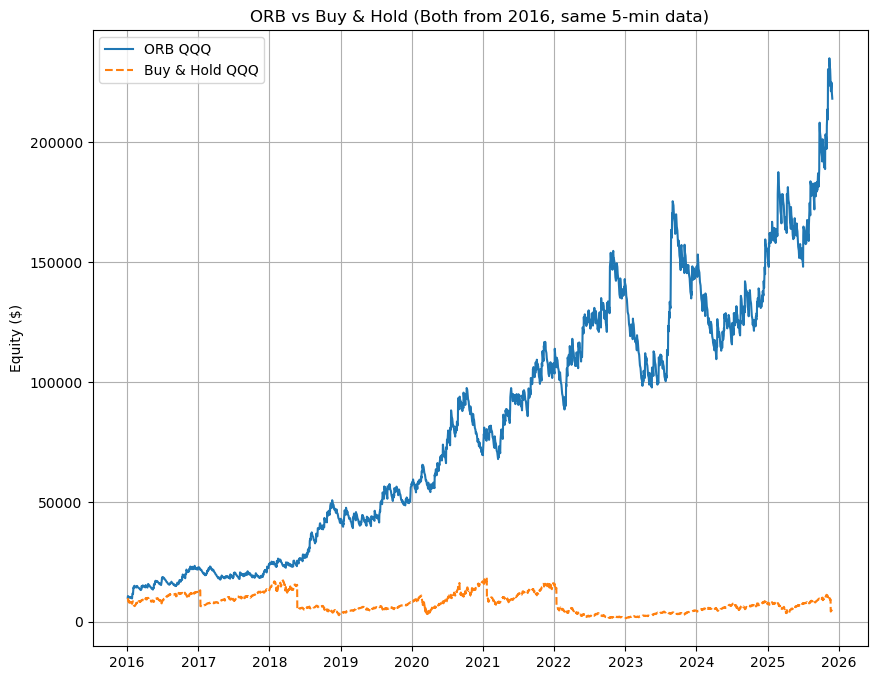

In [81]:
plt.figure(figsize=(10, 8))
plt.plot(orb_equity_aligned, label="ORB QQQ")
plt.plot(bh_equity_aligned, linestyle="--", label="Buy & Hold QQQ")
plt.legend()
plt.title("ORB vs Buy & Hold (Both from 2016, same 5-min data)")
plt.ylabel("Equity ($)")
plt.grid(True)
plt.show()


In [82]:
# ---------- 1) Helper: fetch daily close prices for a list of symbols ----------
def fetch_daily_closes(symbols, start, end, client=data_client):
    """
    Fetch daily close prices for a list of symbols from Alpaca.
    Returns a DataFrame with dates as index and symbols as columns.
    """
    if isinstance(symbols, str):
        symbols = [symbols]

    req = StockBarsRequest(
        symbol_or_symbols=symbols,
        timeframe=TimeFrame.Day,
        start=start,
        end=end,
    )
    bars = client.get_stock_bars(req).df  # MultiIndex: (symbol, timestamp)

    if bars.empty:
        raise ValueError("No bar data returned. Check symbols and dates.")

    # Pivot to wide format: index = date, columns = symbol
    closes = bars["close"].unstack("symbol")

    # Make index tz-naive dates for convenience
    closes.index = pd.to_datetime(closes.index).tz_localize(None)

    # Sort by date just in case
    closes = closes.sort_index()

    return closes


# ---------- 2) Wrapper: compute correlations for your ETF list ----------
def etf_correlation_wrapper(symbols, start, end, min_obs=100, client=data_client):
    """
    Given a list of symbols and a date range, fetch daily closes,
    compute daily returns, and return the correlation matrix.

    Parameters
    ----------
    symbols : list[str] or str
        Tickers to analyze.
    start, end : str or datetime
        Start and end dates (e.g. '2020-01-01', '2025-12-01').
    min_obs : int
        Minimum number of non-NaN observations required to keep a symbol.
    client : StockHistoricalDataClient
        Alpaca data client (defaults to global data_client).

    Returns
    -------
    corr : pd.DataFrame
        Correlation matrix of daily returns (symbols x symbols).
    rets : pd.DataFrame
        Daily return series used to compute the correlations.
    """
    closes = fetch_daily_closes(symbols, start, end, client=client)

    # Drop symbols with too little data
    valid = closes.count(axis=0) >= min_obs
    closes = closes.loc[:, valid]

    if closes.shape[1] == 0:
        raise ValueError("No symbols have at least min_obs observations.")

    # Daily simple returns
    rets = closes.pct_change().dropna(how="all")

    # Drop days where everything is NaN
    rets = rets.dropna(how="all")

    corr = rets.corr()

    print(
        f"Correlation matrix for {len(rets.columns)} symbols "
        f"over {len(rets)} trading days "
        f"({rets.index.min().date()} → {rets.index.max().date()})"
    )
    display(corr)

    return corr, rets


In [83]:
my_etfs = ["TQQQ", "TECL", "BULZ", "SSO", "URTY", "GGLL", "TSLL", "NVDL", "MSTX"]
corr, rets = etf_correlation_wrapper(
    symbols=my_etfs,
    start="2020-01-01",
    end="2025-12-01",
    min_obs=200,
)


Correlation matrix for 9 symbols over 1485 trading days (2020-01-03 → 2025-11-28)


symbol,BULZ,GGLL,MSTX,NVDL,SSO,TECL,TQQQ,TSLL,URTY
symbol,,,,,,,,,
BULZ,1.000000,0.085120,0.009995,0.672866,0.136203,0.180790,0.172939,0.107280,0.165072
GGLL,0.085120,1.000000,0.012998,0.354177,0.483261,0.607097,0.625753,0.396047,0.445096
MSTX,0.009995,0.012998,1.000000,0.044804,0.027395,0.040149,0.038887,0.065926,0.040488
NVDL,0.672866,0.354177,0.044804,1.000000,0.432557,0.717109,0.606761,0.352928,0.338895
SSO,0.136203,0.483261,0.027395,0.432557,1.000000,0.668215,0.827455,0.436299,0.675047
TECL,0.180790,0.607097,0.040149,0.717109,0.668215,1.000000,0.820105,0.533844,0.695057
TQQQ,0.172939,0.625753,0.038887,0.606761,0.827455,0.820105,1.000000,0.554010,0.699012
TSLL,0.107280,0.396047,0.065926,0.352928,0.436299,0.533844,0.554010,1.000000,0.484320
URTY,0.165072,0.445096,0.040488,0.338895,0.675047,0.695057,0.699012,0.484320,1.000000


Correlation matrix for 9 symbols over 1485 trading days (2020-01-03 → 2025-11-28)


symbol,BULZ,GGLL,MSTX,NVDL,SSO,TECL,TQQQ,TSLL,URTY
symbol,,,,,,,,,
BULZ,1.000000,0.085120,0.009995,0.672866,0.136203,0.180790,0.172939,0.107280,0.165072
GGLL,0.085120,1.000000,0.012998,0.354177,0.483261,0.607097,0.625753,0.396047,0.445096
MSTX,0.009995,0.012998,1.000000,0.044804,0.027395,0.040149,0.038887,0.065926,0.040488
NVDL,0.672866,0.354177,0.044804,1.000000,0.432557,0.717109,0.606761,0.352928,0.338895
SSO,0.136203,0.483261,0.027395,0.432557,1.000000,0.668215,0.827455,0.436299,0.675047
TECL,0.180790,0.607097,0.040149,0.717109,0.668215,1.000000,0.820105,0.533844,0.695057
TQQQ,0.172939,0.625753,0.038887,0.606761,0.827455,0.820105,1.000000,0.554010,0.699012
TSLL,0.107280,0.396047,0.065926,0.352928,0.436299,0.533844,0.554010,1.000000,0.484320
URTY,0.165072,0.445096,0.040488,0.338895,0.675047,0.695057,0.699012,0.484320,1.000000


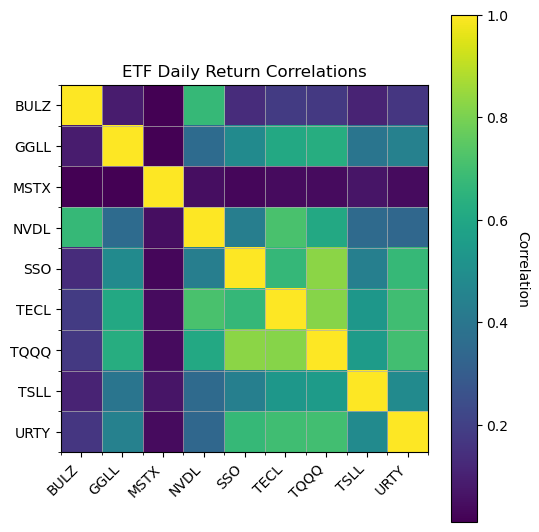

In [84]:
import matplotlib.pyplot as plt
import numpy as np

def plot_corr_heatmap(corr, title="Correlation Heatmap"):
    """
    Plot a correlation heatmap from a pandas DataFrame.

    Parameters
    ----------
    corr : pd.DataFrame
        Correlation matrix (square, symbols x symbols).
    title : str
        Title for the plot.
    """
    symbols = corr.columns.to_list()
    data = corr.values

    fig, ax = plt.subplots(figsize=(1 + 0.5*len(symbols), 1 + 0.5*len(symbols)))

    im = ax.imshow(data, interpolation="nearest")

    # Tick labels
    ax.set_xticks(np.arange(len(symbols)))
    ax.set_yticks(np.arange(len(symbols)))
    ax.set_xticklabels(symbols, rotation=45, ha="right")
    ax.set_yticklabels(symbols)

    # Minor grid lines
    ax.set_xticks(np.arange(-.5, len(symbols), 1), minor=True)
    ax.set_yticks(np.arange(-.5, len(symbols), 1), minor=True)
    ax.grid(which="minor", linestyle="-", linewidth=0.5)

    # Colorbar
    cbar = plt.colorbar(im, ax=ax)
    cbar.ax.set_ylabel("Correlation", rotation=270, labelpad=15)

    ax.set_title(title)
    fig.tight_layout()
    plt.show()

# Example usage after etf_correlation_wrapper:
corr, rets = etf_correlation_wrapper(my_etfs, "2020-01-01", "2025-12-01")
plot_corr_heatmap(corr, title="ETF Daily Return Correlations")


ORB return correlation matrix for 9 symbols over 1486 trading days (2020-01-02 → 2025-11-28)


,TQQQ,TECL,BULZ,SSO,URTY,GGLL,TSLL,NVDL,MSTX
TQQQ,1.000000,0.614767,0.484583,0.446394,0.068973,0.114412,0.163626,0.180581,0.025501
TECL,0.614767,1.000000,0.366450,0.364593,0.049120,0.073919,0.149328,0.208227,0.089313
BULZ,0.484583,0.366450,1.000000,0.236144,0.084057,0.088465,0.136077,0.183004,0.018124
SSO,0.446394,0.364593,0.236144,1.000000,0.253882,0.043929,0.117147,0.047940,-0.007158
URTY,0.068973,0.049120,0.084057,0.253882,1.000000,-0.027338,0.014543,0.002322,-0.012998
GGLL,0.114412,0.073919,0.088465,0.043929,-0.027338,1.000000,0.049373,0.065919,0.002374
TSLL,0.163626,0.149328,0.136077,0.117147,0.014543,0.049373,1.000000,0.059749,0.072136
NVDL,0.180581,0.208227,0.183004,0.047940,0.002322,0.065919,0.059749,1.000000,0.092228
MSTX,0.025501,0.089313,0.018124,-0.007158,-0.012998,0.002374,0.072136,0.092228,1.000000


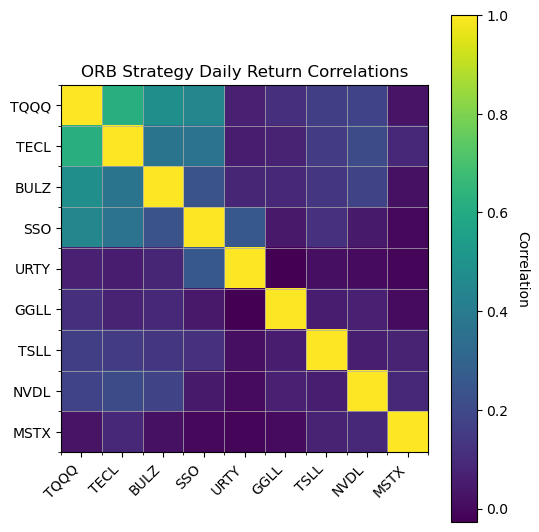

In [85]:
# ---------- 1) Fetch 5-min bars for multiple symbols ----------
def fetch_5min_bars_multi(symbols, start, end, client=data_client):
    """
    Fetch 5-minute bars for multiple symbols from Alpaca.
    Returns a MultiIndex DataFrame indexed by (symbol, timestamp).
    """
    if isinstance(symbols, str):
        symbols = [symbols]

    req = StockBarsRequest(
        symbol_or_symbols=symbols,
        timeframe=TimeFrame(5, TimeFrameUnit.Minute),
        start=start,
        end=end,
    )
    bars = client.get_stock_bars(req).df  # MultiIndex: (symbol, timestamp)

    if bars.empty:
        raise ValueError("No 5-min bar data returned. Check symbols and dates.")

    # Ensure timestamp is NY time and regular hours only
    bars = bars.copy()
    # level 1 is timestamp
    idx = bars.index
    ts = idx.get_level_values("timestamp").tz_convert("America/New_York")
    bars.index = pd.MultiIndex.from_arrays(
        [idx.get_level_values("symbol"), ts],
        names=["symbol", "timestamp"]
    )

    # Restrict to regular trading hours
    bars = bars.groupby(level="symbol").apply(
        lambda df: df.droplevel(0).between_time("09:30", "16:00")
    )
    # That groupby adds a level back; fix index to (symbol, timestamp)
    bars.index = bars.index.set_names(["symbol", "timestamp"])

    return bars


# ---------- 2) Run ORB per symbol and collect daily returns ----------
def run_orb_on_universe(symbols, start, end, client=data_client):
    """
    For each symbol, run the ORB strategy and return:
      - orb_rets_df: DataFrame of daily ORB returns per symbol
      - orb_equity_dict: dict of equity curves per symbol
    Assumes backtest_orb_5m(bars_5m, ...) -> (equity, daily_rets, trades).
    """
    bars_all = fetch_5min_bars_multi(symbols, start, end, client=client)

    rets_dict = {}
    equity_dict = {}

    for sym in symbols:
        try:
            bars_sym = bars_all.xs(sym, level="symbol")
        except KeyError:
            print(f"No bars for {sym}, skipping.")
            continue

        # Run your existing ORB backtest; tweak args as needed
        eq, rets, trades = backtest_orb_5m(bars_sym)

        # Normalize index to dates only for alignment
        rets.index = pd.to_datetime(rets.index).normalize()
        eq.index   = pd.to_datetime(eq.index).normalize()

        rets_dict[sym]   = rets
        equity_dict[sym] = eq

    # Combine daily returns; missing days = 0 (no trade)
    orb_rets_df = pd.DataFrame(rets_dict).sort_index().fillna(0.0)

    return orb_rets_df, equity_dict


# ---------- 3) Plot ORB return correlation heatmap ----------
def plot_corr_heatmap(corr, title="ORB Return Correlations"):
    symbols = corr.columns.to_list()
    data = corr.values

    fig, ax = plt.subplots(figsize=(1 + 0.5*len(symbols), 1 + 0.5*len(symbols)))

    im = ax.imshow(data, interpolation="nearest")

    ax.set_xticks(np.arange(len(symbols)))
    ax.set_yticks(np.arange(len(symbols)))
    ax.set_xticklabels(symbols, rotation=45, ha="right")
    ax.set_yticklabels(symbols)

    ax.set_xticks(np.arange(-.5, len(symbols), 1), minor=True)
    ax.set_yticks(np.arange(-.5, len(symbols), 1), minor=True)
    ax.grid(which="minor", linestyle="-", linewidth=0.5)

    cbar = plt.colorbar(im, ax=ax)
    cbar.ax.set_ylabel("Correlation", rotation=270, labelpad=15)

    ax.set_title(title)
    fig.tight_layout()
    plt.show()


# ---------- 4) Run it on your current ETF list ----------
START = "2020-01-01"
END   = "2025-12-01"

my_etfs = ["TQQQ", "TECL", "BULZ", "SSO", "URTY", "GGLL", "TSLL", "NVDL", "MSTX"]

orb_rets_df, equity_dict = run_orb_on_universe(
    symbols=my_etfs,
    start=START,
    end=END,
    client=data_client,
)

# Correlation of ORB daily returns
orb_corr = orb_rets_df.corr()
print(
    f"ORB return correlation matrix for {len(orb_rets_df.columns)} symbols "
    f"over {len(orb_rets_df)} trading days "
    f"({orb_rets_df.index.min().date()} → {orb_rets_df.index.max().date()})"
)
display(orb_corr)

plot_corr_heatmap(orb_corr, title="ORB Strategy Daily Return Correlations")


Sample: 2020-01-02 → 2025-11-28  (1486 trading days)


,CAGR %,Ann. Vol %,Sharpe,MaxDD %,Total Return %
TQQQ,25.48,36.92,0.69,-37.54,281.32
TECL,21.20,35.41,0.60,-43.70,210.67
BULZ,24.09,30.68,0.79,-42.42,257.09
SSO,9.19,34.42,0.27,-43.27,67.93
URTY,29.69,37.52,0.79,-48.51,363.21
GGLL,27.57,24.08,1.14,-33.45,320.24
TSLL,18.98,23.45,0.81,-28.36,178.67
NVDL,15.23,22.47,0.68,-22.63,130.72
MSTX,4.70,16.99,0.28,-32.97,31.12
Portfolio (EW),23.19,14.95,1.55,-14.75,242.05


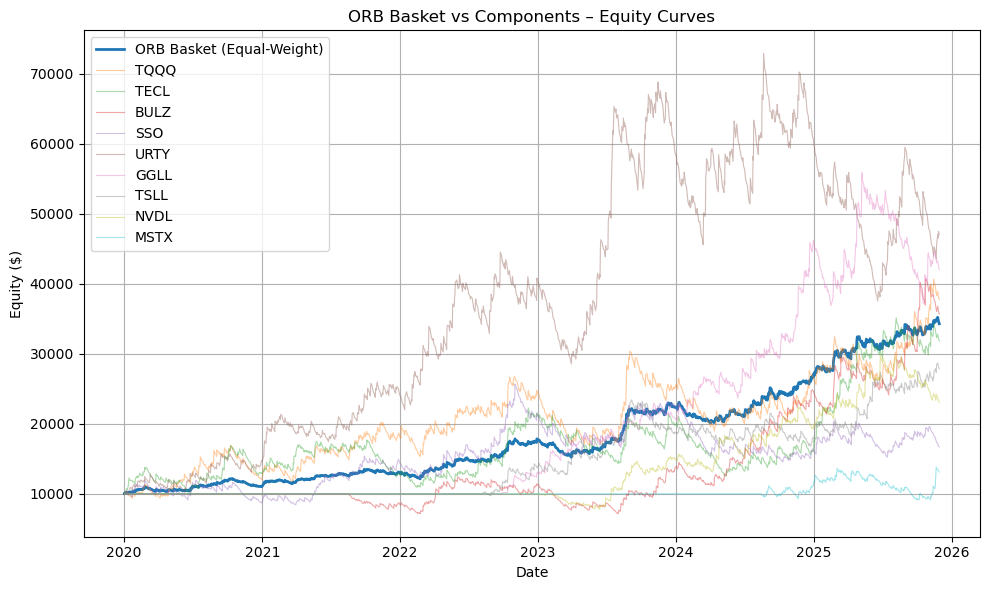

In [86]:

# ==== CONFIG ====
# Use whatever starting capital you've been using in your ORB tests
START_CAPITAL = 10_000  # change if needed

# ==== 1) Helper: performance stats from daily returns ====
def perf_stats_from_rets(rets: pd.Series, start_capital: float = START_CAPITAL):
    """
    Compute performance statistics from a daily return series.
    Returns a dict with CAGR, Annual Vol, Sharpe, MaxDD, Total Return.
    """
    rets = rets.dropna()
    if len(rets) < 2:
        return {k: np.nan for k in ["CAGR", "Annual Vol", "Sharpe", "MaxDD", "Total Return"]}

    equity = (1 + rets).cumprod() * start_capital
    n_days = len(rets)

    start_val = equity.iloc[0]
    end_val   = equity.iloc[-1]

    cagr = (end_val / start_val) ** (252 / n_days) - 1
    vol  = rets.std() * np.sqrt(252)
    sharpe = cagr / vol if vol > 0 else np.nan

    running_max = equity.cummax()
    dd = equity / running_max - 1
    max_dd = dd.min()

    total_ret = end_val / start_val - 1

    return {
        "CAGR": cagr,
        "Annual Vol": vol,
        "Sharpe": sharpe,
        "MaxDD": max_dd,
        "Total Return": total_ret,
    }

# ==== 2) Build per-symbol and portfolio equity curves ====
# orb_rets_df: index = dates, columns = symbols, values = daily ORB returns per symbol
# (we built this earlier in run_orb_on_universe)

# Equal-weighted portfolio returns (average across symbols each day)
portfolio_rets = orb_rets_df.mean(axis=1)

# Equity curves
equity_by_symbol = (1 + orb_rets_df).cumprod() * START_CAPITAL
portfolio_equity = (1 + portfolio_rets).cumprod() * START_CAPITAL

# ==== 3) Summary table of stats ====
summary = {}

for sym in orb_rets_df.columns:
    summary[sym] = perf_stats_from_rets(orb_rets_df[sym], START_CAPITAL)

summary["Portfolio (EW)"] = perf_stats_from_rets(portfolio_rets, START_CAPITAL)

summary_df = pd.DataFrame(summary).T

def to_pct(x):
    return float(x) * 100 if pd.notnull(x) else np.nan

summary_pretty = pd.DataFrame({
    "CAGR %":        summary_df["CAGR"].apply(to_pct),
    "Ann. Vol %":    summary_df["Annual Vol"].apply(to_pct),
    "Sharpe":        summary_df["Sharpe"],
    "MaxDD %":       summary_df["MaxDD"].apply(to_pct),
    "Total Return %":summary_df["Total Return"].apply(to_pct),
})

print(
    f"Sample: {orb_rets_df.index.min().date()} → {orb_rets_df.index.max().date()}  "
    f"({len(orb_rets_df)} trading days)"
)
display(summary_pretty.round(2))

# ==== 4) Plot equity curves ====
plt.figure(figsize=(10, 6))

# Plot portfolio equity
plt.plot(portfolio_equity, label="ORB Basket (Equal-Weight)", linewidth=2)

# Optionally, plot individual symbols (light)
for sym in equity_by_symbol.columns:
    plt.plot(equity_by_symbol[sym], alpha=0.4, linewidth=0.8, label=sym)

plt.title("ORB Basket vs Components – Equity Curves")
plt.ylabel("Equity ($)")
plt.xlabel("Date")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


Train period: 2020-01-02 → 2022-12-30 (756 trading days)
Test period:  2023-01-03 → 2025-11-28 (730 trading days)

=== ORB Basket – Train/Test Performance ===


,CAGR %,Ann. Vol %,Sharpe,MaxDD %,Total Return %
Train,20.98,13.63,1.54,-10.19,77.05
Test,25.69,16.21,1.58,-13.96,93.92
Full,23.19,14.95,1.55,-14.75,242.05


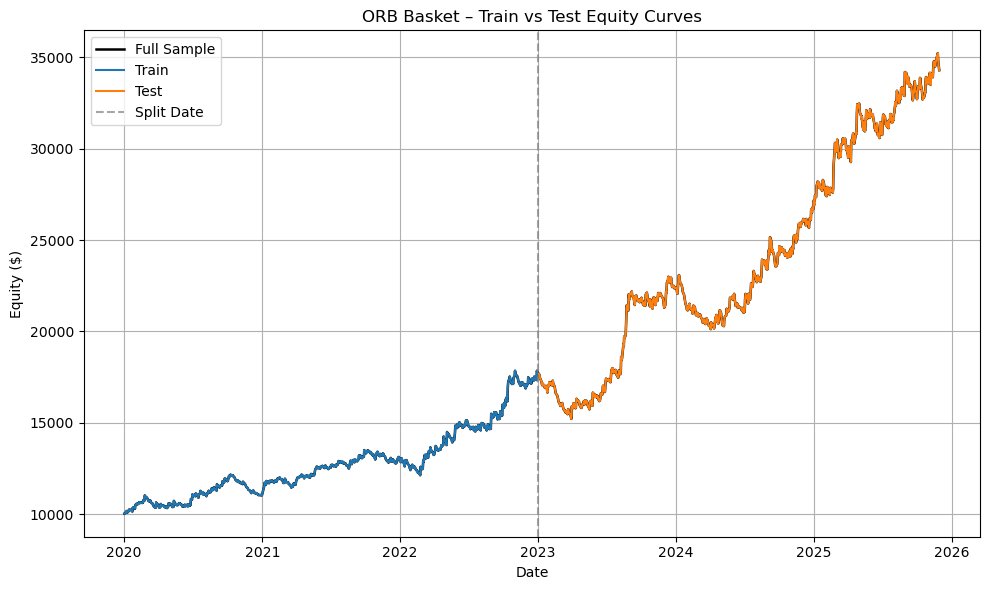

In [87]:
# === CONFIG: choose your split date for train vs test ===
# Change this to whatever makes sense: e.g. '2021-01-01', '2022-06-30', etc.
split_date = pd.Timestamp("2023-01-01")

# Ensure DateTime index
prt = portfolio_rets.copy()
prt.index = pd.to_datetime(prt.index)

# --- Train / Test split ---
train_rets = prt[prt.index <= split_date]
test_rets  = prt[prt.index >  split_date]

print(f"Train period: {train_rets.index.min().date()} → {train_rets.index.max().date()} "
      f"({len(train_rets)} trading days)")
print(f"Test period:  {test_rets.index.min().date()} → {test_rets.index.max().date()} "
      f"({len(test_rets)} trading days)")

# --- Stats ---
train_stats = perf_stats_from_rets(train_rets, START_CAPITAL)
test_stats  = perf_stats_from_rets(test_rets,  START_CAPITAL)
full_stats  = perf_stats_from_rets(prt,        START_CAPITAL)

def to_pct(x):
    return float(x) * 100 if pd.notnull(x) else float("nan")

summary_tt = pd.DataFrame(
    {
        "CAGR %":        [to_pct(train_stats["CAGR"]),        to_pct(test_stats["CAGR"]),        to_pct(full_stats["CAGR"])],
        "Ann. Vol %":    [to_pct(train_stats["Annual Vol"]),  to_pct(test_stats["Annual Vol"]),  to_pct(full_stats["Annual Vol"])],
        "Sharpe":        [train_stats["Sharpe"],              test_stats["Sharpe"],              full_stats["Sharpe"]],
        "MaxDD %":       [to_pct(train_stats["MaxDD"]),       to_pct(test_stats["MaxDD"]),       to_pct(full_stats["MaxDD"])],
        "Total Return %":[to_pct(train_stats["Total Return"]), to_pct(test_stats["Total Return"]), to_pct(full_stats["Total Return"])],
    },
    index=["Train", "Test", "Full"],
)

print("\n=== ORB Basket – Train/Test Performance ===")
display(summary_tt.round(2))

# --- Equity curves for visualization ---
train_equity = (1 + train_rets).cumprod() * START_CAPITAL
# Start test equity where train left off so it's one continuous curve
test_equity  = (1 + test_rets).cumprod() * (train_equity.iloc[-1] if len(train_equity) else START_CAPITAL)
full_equity  = (1 + prt).cumprod() * START_CAPITAL

plt.figure(figsize=(10, 6))
plt.plot(full_equity, label="Full Sample", color="black", linewidth=1.8)
plt.plot(train_equity, label="Train", linewidth=1.5)
plt.plot(test_equity,  label="Test",  linewidth=1.5)

plt.axvline(split_date, color="gray", linestyle="--", alpha=0.7, label="Split Date")
plt.title("ORB Basket – Train vs Test Equity Curves")
plt.ylabel("Equity ($)")
plt.xlabel("Date")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

Calculating Factor Coefficients w/ Version 1

In [88]:
# === 1) Load Fama–French 5-factor daily data ===
ff5_path = r"C:\Users\Jonbf5\OneDrive - University of Cincinnati\Classes\FIN7053 Algorithmic Trading\F-F_Research_Data_5_Factors_2x3_daily.csv"

# Load, skipping the description header
ff5_raw = pd.read_csv(ff5_path, skiprows=3)

# Rename first column to 'date'
ff5_raw = ff5_raw.rename(columns={"Unnamed: 0": "date"})

# Convert date column to datetime, drop footer rows (NaT)
ff5_raw["date"] = pd.to_datetime(ff5_raw["date"], format="%Y%m%d", errors="coerce")
ff5_raw = ff5_raw.dropna(subset=["date"])

# Set date as index
ff5 = ff5_raw.set_index("date")

# Keep only the factor columns we need and convert % → decimal
for col in ["Mkt-RF", "SMB", "HML", "RMW", "CMA", "RF"]:
    ff5[col] = ff5[col].astype(float) / 100.0


# === 2) Align ORB basket returns with FF5 dates ===
# portfolio_rets: daily ORB basket returns (decimal)

strat_ret_aligned = portfolio_rets.copy()

# Drop timezone if present, normalize to date
idx = strat_ret_aligned.index
if getattr(idx, "tz", None) is not None:
    strat_ret_aligned.index = idx.tz_convert(None).normalize()
else:
    strat_ret_aligned.index = pd.to_datetime(idx).normalize()


# Inner join on dates
data = pd.concat(
    [strat_ret_aligned.rename("strat_ret"), ff5],
    axis=1,
    join="inner"
).dropna()


# === 3) Excess return of strategy ===
data["strat_excess"] = data["strat_ret"] - data["RF"]

# === 4) Prepare X (factors) and y (excess return) ===
X = data[["Mkt-RF", "SMB", "HML", "RMW", "CMA"]]
X = sm.add_constant(X)
y = data["strat_excess"]


# === 5) Run Fama–French 5-factor regression with HAC standard errors ===
model = sm.OLS(y, X).fit(cov_type="HAC", cov_kwds={"maxlags": 5})
print(model.summary())

# === 6) Annualized alpha ===
daily_alpha = model.params["const"]
ann_alpha   = daily_alpha * 252

print(f"\nDaily alpha: {daily_alpha:.6f}")
print(f"Annualized alpha: {ann_alpha:.4%}")

                            OLS Regression Results                            
Dep. Variable:           strat_excess   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                 -0.002
Method:                 Least Squares   F-statistic:                    0.4463
Date:                Tue, 02 Dec 2025   Prob (F-statistic):              0.816
Time:                        11:19:39   Log-Likelihood:                 4761.9
No. Observations:                1467   AIC:                            -9512.
Df Residuals:                    1461   BIC:                            -9480.
Df Model:                           5                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0008      0.000      3.294      0.0

Testing the Strategy with Slippage

In [89]:
def backtest_orb_5m_slippage(
    bars_5m,
    slippage_bps=0.0,         # e.g., 0.0002 = 2 bps each side
    start_capital=START_CAPITAL,
    risk_pct=RISK_PCT,
    max_leverage=MAX_LEVERAGE,
    commission_per_share=COMMISSION_PER_SHARE,
    profit_mult=10.0,
):
    """
    Same ORB logic, but adds slippage to entry/exit prices.
    slippage_bps = fraction (0.0001 = 1bp = 0.01%)
    """

    equity = start_capital
    equity_curve = []
    daily_returns = []
    trades = []

    # Group by trading day
    for day, df_day in bars_5m.groupby(bars_5m.index.date):

        df_day = df_day.sort_index()

        if len(df_day) < 2:
            equity_curve.append(equity)
            daily_returns.append(0)
            continue

        first = df_day.iloc[0]
        second = df_day.iloc[1]

        if np.isclose(first["close"], first["open"]):
            equity_curve.append(equity)
            daily_returns.append(0)
            continue

        direction = 1 if first["close"] > first["open"] else -1
        entry_price_raw = second["open"]

        # Slippage at ENTRY
        entry_price = entry_price_raw * (1 + direction * slippage_bps)

        if direction == 1:
            stop_price_raw = first["low"]
            R = entry_price_raw - stop_price_raw
        else:
            stop_price_raw = first["high"]
            R = stop_price_raw - entry_price_raw

        if R <= 0:
            equity_curve.append(equity)
            daily_returns.append(0)
            continue

        # SLIPPAGE-ADJUSTED stop price (still use raw to compare logic)
        stop_price = stop_price_raw * (1 - direction * slippage_bps)

        # Target (raw)
        if direction == 1:
            target_price_raw = entry_price_raw + profit_mult * R
        else:
            target_price_raw = entry_price_raw - profit_mult * R

        # Slippage-adjusted exit target
        target_price = target_price_raw * (1 - direction * slippage_bps)

        account_risk = equity * risk_pct
        shares = account_risk / R
        shares = int(min(shares, (equity * max_leverage) / entry_price))

        if shares <= 0:
            equity_curve.append(equity)
            daily_returns.append(0)
            continue

        exit_price = None
        exit_reason = None

        for ts, bar in df_day.iloc[2:].iterrows():
            if direction == 1:
                if bar["low"] <= stop_price_raw:
                    exit_price = stop_price
                    exit_reason = "STOP"
                    break
                if bar["high"] >= target_price_raw:
                    exit_price = target_price
                    exit_reason = "TARGET"
                    break
            else:
                if bar["high"] >= stop_price_raw:
                    exit_price = stop_price
                    exit_reason = "STOP"
                    break
                if bar["low"] <= target_price_raw:
                    exit_price = target_price
                    exit_reason = "TARGET"
                    break

        if exit_price is None:
            raw_exit = df_day.iloc[-1]["close"]
            exit_price = raw_exit * (1 - direction * slippage_bps)
            exit_reason = "EOD"

        pnl_per_share = (exit_price - entry_price) * direction
        gross_pnl = pnl_per_share * shares
        commission = commission_per_share * shares * 2
        net_pnl = gross_pnl - commission

        equity_start = equity
        equity += net_pnl
        daily_returns.append(net_pnl / equity_start)
        equity_curve.append(equity)

    eq_df = pd.Series(equity_curve, index=pd.to_datetime(pd.Series(bars_5m.index.date).unique()))
    ret_df = pd.Series(daily_returns, index=eq_df.index)

    return eq_df, ret_df, None


In [90]:
slips = {
    "0bp": 0.0,
    "1bp": 0.0001,
    "2bp": 0.0002,
    "3bp": 0.0003,
    "5bp": 0.005,
}

results = {}

for name, slip in slips.items():
    orb_eq, orb_rets, _ = backtest_orb_5m_slippage(bars_5m, slippage_bps=slip)
    stats = perf_stats_from_rets(orb_rets)
    results[name] = stats

pd.DataFrame(results).T


,CAGR,Annual Vol,Sharpe,MaxDD,Total Return
0bp,0.653694,0.395580,1.652493,-0.363679,143.636427
1bp,0.504787,0.395437,1.276530,-0.379984,55.889278
2bp,0.368993,0.395249,0.933571,-0.395856,21.328275
3bp,0.245301,0.395058,0.620925,-0.426308,7.753041
5bp,-0.516250,0.189647,-2.722166,-0.999274,-0.999239


In [91]:

# ====== CONFIG (you can tweak these) ======
START_DATE = "2023-01-01"      # or whatever your start is
END_DATE   = "2025-12-01"

START_CAPITAL = 10_000.0       # starting equity
RISK_PCT = 0.01                # 1% risk per trade
MAX_LEVERAGE = 2.0
COMMISSION_PER_SHARE = 0.0005  # per side
ATR_FRAC = 0.05                # 5% of 14-day ATR for stop distance
SLIPPAGE_BPS = 0.0002          # 2 bps per side


# ====== Helper: performance stats from daily returns ======
def perf_stats_from_rets(rets: pd.Series, start_capital: float = START_CAPITAL):
    rets = rets.dropna()
    if len(rets) < 2:
        return {k: np.nan for k in ["CAGR", "Annual Vol", "Sharpe", "MaxDD", "Total Return"]}

    equity = (1 + rets).cumprod() * start_capital
    n_days = len(rets)

    start_val = equity.iloc[0]
    end_val   = equity.iloc[-1]

    cagr = (end_val / start_val) ** (252 / n_days) - 1
    vol  = rets.std() * np.sqrt(252)
    sharpe = cagr / vol if vol > 0 else np.nan

    running_max = equity.cummax()
    dd = equity / running_max - 1
    max_dd = dd.min()

    total_ret = end_val / start_val - 1

    return {
        "CAGR": cagr,
        "Annual Vol": vol,
        "Sharpe": sharpe,
        "MaxDD": max_dd,
        "Total Return": total_ret,
    }


# ====== Helper: ATR14 from daily OHLC ======
def compute_atr14(daily_df: pd.DataFrame, window: int = 14) -> pd.Series:
    """
    Compute ATR(14) from daily OHLC data.
    Expects columns: 'high', 'low', 'close'.
    Returns a pd.Series indexed by date.
    """
    high = daily_df["high"]
    low = daily_df["low"]
    close = daily_df["close"]

    prev_close = close.shift(1)

    tr1 = high - low
    tr2 = (high - prev_close).abs()
    tr3 = (low - prev_close).abs()

    tr = pd.concat([tr1, tr2, tr3], axis=1).max(axis=1)
    atr14 = tr.rolling(window).mean()
    return atr14


# ====== Fetch daily and 5-min bars for all symbols ======
def fetch_daily_and_5m(symbols, start, end, client):
    if isinstance(symbols, str):
        symbols = [symbols]

    # Daily bars
    daily_req = StockBarsRequest(
        symbol_or_symbols=symbols,
        timeframe=TimeFrame.Day,
        start=start,
        end=end,
    )
    daily_bars_all = client.get_stock_bars(daily_req).df  # MultiIndex: (symbol, timestamp)

    # 5-min bars
    intraday_req = StockBarsRequest(
        symbol_or_symbols=symbols,
        timeframe=TimeFrame(5, TimeFrameUnit.Minute),
        start=start,
        end=end,
    )
    intraday_bars_all = client.get_stock_bars(intraday_req).df  # MultiIndex: (symbol, timestamp)

    # Normalize intraday to NY time & RTH only
    idx = intraday_bars_all.index
    ts = idx.get_level_values("timestamp").tz_convert("America/New_York")
    intraday_bars_all.index = pd.MultiIndex.from_arrays(
        [idx.get_level_values("symbol"), ts],
        names=["symbol", "timestamp"]
    )
    intraday_bars_all = intraday_bars_all.groupby(level="symbol").apply(
        lambda df: df.droplevel(0).between_time("09:30", "16:00")
    )
    intraday_bars_all.index = intraday_bars_all.index.set_names(["symbol", "timestamp"])

    # Build per-symbol dicts
    daily_dict = {}
    intraday_dict = {}

    for sym in symbols:
        # Daily
        try:
            d_sym = daily_bars_all.xs(sym, level="symbol").copy()
        except KeyError:
            continue
        d_sym.index = pd.to_datetime(d_sym.index).tz_localize(None).normalize()
        d_sym = d_sym.sort_index()
        daily_dict[sym] = d_sym

        # 5-min
        try:
            i_sym = intraday_bars_all.xs(sym, level="symbol").copy()
        except KeyError:
            continue
        intraday_dict[sym] = i_sym.sort_index()

    return daily_dict, intraday_dict


# ====== ATR-based ORB backtest for one symbol ======
def backtest_orb_5m_atr(
    bars_5m: pd.DataFrame,
    atr_series: pd.Series,
    atr_frac: float = ATR_FRAC,
    slippage_bps: float = SLIPPAGE_BPS,
    start_capital: float = START_CAPITAL,
    risk_pct: float = RISK_PCT,
    max_leverage: float = MAX_LEVERAGE,
    commission_per_share: float = COMMISSION_PER_SHARE,
):
    equity = start_capital
    equity_curve = []
    daily_returns = []

    atr = atr_series.copy()
    atr.index = pd.to_datetime(atr.index).normalize()

    days = list(bars_5m.groupby(bars_5m.index.date))

    for day, df_day in days:
        df_day = df_day.sort_index()

        if len(df_day) < 2:
            equity_curve.append(equity)
            daily_returns.append(0.0)
            continue

        day_dt = pd.to_datetime(day).normalize()
        day_atr = atr.get(day_dt, np.nan)

        if pd.isna(day_atr) or day_atr <= 0:
            equity_curve.append(equity)
            daily_returns.append(0.0)
            continue

        first = df_day.iloc[0]
        second = df_day.iloc[1]

        # Skip doji first candle
        if np.isclose(first["close"], first["open"]):
            equity_curve.append(equity)
            daily_returns.append(0.0)
            continue

        direction = 1 if first["close"] > first["open"] else -1

        entry_price_raw = second["open"]
        entry_price = entry_price_raw * (1 + direction * slippage_bps)

        # ATR-based stop distance
        stop_dist = atr_frac * day_atr
        if stop_dist <= 0:
            equity_curve.append(equity)
            daily_returns.append(0.0)
            continue

        if direction == 1:
            stop_price_raw = entry_price_raw - stop_dist
        else:
            stop_price_raw = entry_price_raw + stop_dist

        if stop_price_raw <= 0:
            equity_curve.append(equity)
            daily_returns.append(0.0)
            continue

        R = stop_dist

        # Position sizing: 1% risk, capped by leverage
        account_risk = equity * risk_pct
        shares = account_risk / R
        shares = int(min(shares, (equity * max_leverage) / entry_price))

        if shares <= 0:
            equity_curve.append(equity)
            daily_returns.append(0.0)
            continue

        exit_price = None

        # Intraday: only stop, no profit target
        for ts, bar in df_day.iloc[2:].iterrows():
            if direction == 1:
                if bar["low"] <= stop_price_raw:
                    exit_price = stop_price_raw * (1 - direction * slippage_bps)
                    break
            else:
                if bar["high"] >= stop_price_raw:
                    exit_price = stop_price_raw * (1 - direction * slippage_bps)
                    break

        if exit_price is None:
            raw_exit = df_day.iloc[-1]["close"]
            exit_price = raw_exit * (1 - direction * slippage_bps)

        pnl_per_share = (exit_price - entry_price) * direction
        gross_pnl = pnl_per_share * shares
        commission = commission_per_share * shares * 2
        net_pnl = gross_pnl - commission

        equity_start = equity
        equity += net_pnl
        day_ret = net_pnl / equity_start

        equity_curve.append(equity)
        daily_returns.append(day_ret)

    unique_days = pd.to_datetime(pd.Series([d for d, _ in days])).dt.normalize().unique()
    eq_series = pd.Series(equity_curve, index=unique_days)
    ret_series = pd.Series(daily_returns, index=unique_days)

    return eq_series, ret_series


# ====== Run ATR-ORB for your basket and compute returns ======
# Assumes you have defined: my_etfs (list of symbols) and data_client
symbols = my_etfs

daily_dict, intraday_dict = fetch_daily_and_5m(symbols, START_DATE, END_DATE, data_client)

rets_dict = {}
eq_dict = {}

for sym in symbols:
    if sym not in daily_dict or sym not in intraday_dict:
        print(f"Skipping {sym}: missing data.")
        continue

    daily = daily_dict[sym]
    intraday = intraday_dict[sym]

    # Compute ATR14 and shift by 1 day (use only past info)
    atr14 = compute_atr14(daily)
    atr14_shifted = atr14.shift(1)

    eq_sym, rets_sym = backtest_orb_5m_atr(
        intraday,
        atr_series=atr14_shifted,
        atr_frac=ATR_FRAC,
        slippage_bps=SLIPPAGE_BPS,
    )

    # Normalize indices to date and store
    rets_sym.index = pd.to_datetime(rets_sym.index).normalize()
    eq_sym.index   = pd.to_datetime(eq_sym.index).normalize()

    rets_dict[sym] = rets_sym
    eq_dict[sym]   = eq_sym

# Combine into a single DataFrame of daily ORB returns per symbol
orb_rets_atr_df = pd.DataFrame(rets_dict).sort_index().fillna(0.0)

# Equal-weight portfolio returns
portfolio_rets_atr = orb_rets_atr_df.mean(axis=1)

# Portfolio equity curve
portfolio_equity_atr = (1 + portfolio_rets_atr).cumprod() * START_CAPITAL

print(f"ATR-ORB basket sample: {portfolio_rets_atr.index.min().date()} → {portfolio_rets_atr.index.max().date()}")
print(f"Number of trading days: {len(portfolio_rets_atr)}")

# Performance stats per symbol + portfolio
summary = {}
for sym in orb_rets_atr_df.columns:
    summary[sym] = perf_stats_from_rets(orb_rets_atr_df[sym], START_CAPITAL)

summary["Portfolio (ATR ORB, EW)"] = perf_stats_from_rets(portfolio_rets_atr, START_CAPITAL)

summary_df = pd.DataFrame(summary).T

def to_pct(x):
    return float(x) * 100 if pd.notnull(x) else np.nan

summary_pretty = pd.DataFrame({
    "CAGR %":         summary_df["CAGR"].apply(to_pct),
    "Ann. Vol %":     summary_df["Annual Vol"].apply(to_pct),
    "Sharpe":         summary_df["Sharpe"],
    "MaxDD %":        summary_df["MaxDD"].apply(to_pct),
    "Total Return %": summary_df["Total Return"].apply(to_pct),
})

print("\n=== ATR-ORB Basket Performance (5% ATR stop, EoD exit, {:.1f} bps slippage) ===".format(SLIPPAGE_BPS*1e4))
display(summary_pretty.round(2))


ATR-ORB basket sample: 2023-01-03 → 2025-11-28
Number of trading days: 730

=== ATR-ORB Basket Performance (5% ATR stop, EoD exit, 2.0 bps slippage) ===


,CAGR %,Ann. Vol %,Sharpe,MaxDD %,Total Return %
TQQQ,77.75,38.06,2.04,-21.26,429.26
TECL,123.03,51.31,2.40,-25.37,921.27
BULZ,253.78,56.96,4.46,-22.04,3786.66
SSO,-7.25,15.39,-0.47,-30.70,-19.59
URTY,60.02,39.69,1.51,-29.06,290.35
GGLL,215.47,57.42,3.75,-13.35,2688.72
TSLL,367.15,70.62,5.20,-19.35,8595.55
NVDL,271.59,64.96,4.18,-23.14,4381.04
MSTX,46.69,49.48,0.94,-42.51,203.39
"Portfolio (ATR ORB, EW)",149.08,25.81,5.78,-8.36,1306.43


In [92]:
# ===== Win rates for ATR-ORB basket (matching the backtest cell) =====

# 1) Portfolio win rate (based on portfolio_rets_atr from your cell)
rets_port = portfolio_rets_atr.copy()

# Days where the portfolio actually had non-zero P&L (i.e., trades happened)
trade_mask_port = rets_port != 0.0
rets_trading_days = rets_port[trade_mask_port]

total_days = len(rets_port)
trading_days = len(rets_trading_days)

wins = (rets_trading_days > 0).sum()
losses = (rets_trading_days < 0).sum()
flats_trade_days = (rets_trading_days == 0).sum()  # usually 0 since we filtered != 0

portfolio_win_rate = wins / trading_days if trading_days > 0 else np.nan

print("=== Portfolio Win Rate (ATR-ORB EW Basket) ===")
print(f"Total calendar days in sample:     {total_days}")
print(f"Days with trades (non-zero P&L):   {trading_days}")
print(f"  Winning days:                    {wins}")
print(f"  Losing days:                     {losses}")
print(f"  Flat trade days:                 {flats_trade_days}")
print(f"Portfolio win rate (trade days):   {portfolio_win_rate:.2%}")

# 2) Per-symbol win rates (based on orb_rets_atr_df from your cell)
per_sym_stats = []

for sym in orb_rets_atr_df.columns:
    r = orb_rets_atr_df[sym].copy()
    trade_mask = r != 0.0
    r_trades = r[trade_mask]

    if len(r_trades) == 0:
        continue

    wins_sym = (r_trades > 0).sum()
    losses_sym = (r_trades < 0).sum()
    flats_sym = (r_trades == 0).sum()
    win_rate_sym = wins_sym / len(r_trades) if len(r_trades) > 0 else np.nan

    per_sym_stats.append({
        "Symbol": sym,
        "Trade Days": len(r_trades),
        "Win Days": wins_sym,
        "Loss Days": losses_sym,
        "Flat Trade Days": flats_sym,
        "Win Rate %": win_rate_sym * 100,
    })

per_sym_df = pd.DataFrame(per_sym_stats).set_index("Symbol").sort_values("Win Rate %", ascending=False)

print("\n=== Per-Symbol Win Rates (on days with trades) ===")
display(per_sym_df.round(2))

=== Portfolio Win Rate (ATR-ORB EW Basket) ===
Total calendar days in sample:     730
Days with trades (non-zero P&L):   716
  Winning days:                    313
  Losing days:                     403
  Flat trade days:                 0
Portfolio win rate (trade days):   43.72%

=== Per-Symbol Win Rates (on days with trades) ===


,Trade Days,Win Days,Loss Days,Flat Trade Days,Win Rate %
Symbol,,,,,
GGLL,703,120,583,0,17.07
TSLL,709,116,593,0,16.36
NVDL,698,112,586,0,16.05
BULZ,707,109,598,0,15.42
TECL,714,102,612,0,14.29
TQQQ,712,99,613,0,13.90
URTY,707,88,619,0,12.45
MSTX,321,38,283,0,11.84
SSO,697,74,623,0,10.62


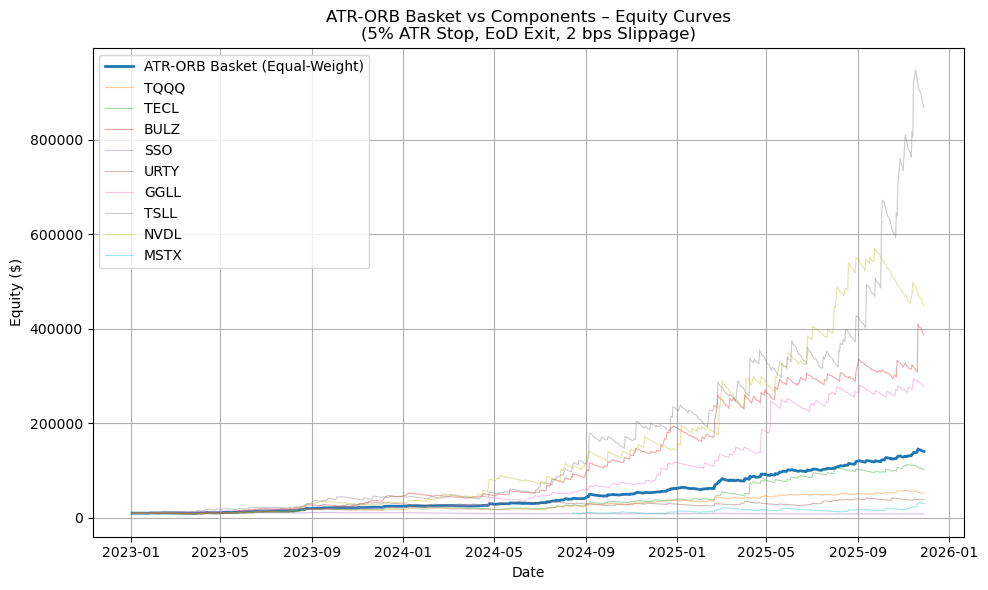

In [93]:
# === ATR-ORB Equity Curves Plot ===

plt.figure(figsize=(10, 6))

# Plot portfolio equity in bold
plt.plot(
    portfolio_equity_atr.index,
    portfolio_equity_atr.values,
    linewidth=2,
    label="ATR-ORB Basket (Equal-Weight)"
)

# Plot each component's equity curve faintly
for sym, eq_series in eq_dict.items():
    plt.plot(
        eq_series.index,
        eq_series.values,
        linewidth=0.8,
        alpha=0.4,
        label=sym
    )

plt.title("ATR-ORB Basket vs Components – Equity Curves\n(5% ATR Stop, EoD Exit, 2 bps Slippage)")
plt.xlabel("Date")
plt.ylabel("Equity ($)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

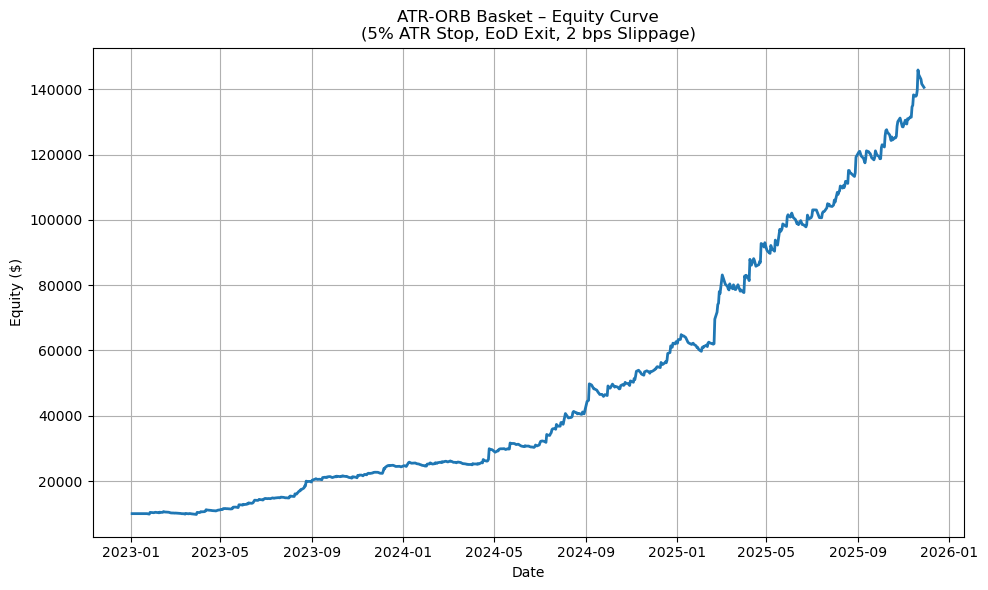

In [94]:
# === ATR-ORB Basket Only – Equity Curve ===

plt.figure(figsize=(10, 6))

plt.plot(
    portfolio_equity_atr.index,
    portfolio_equity_atr.values,
    linewidth=2
)

plt.title("ATR-ORB Basket – Equity Curve\n(5% ATR Stop, EoD Exit, 2 bps Slippage)")
plt.xlabel("Date")
plt.ylabel("Equity ($)")
plt.grid(True)
plt.tight_layout()
plt.show()

In [95]:
# === 1) Load Fama–French 5-Factor daily data ===
ff5_path = r"C:\Users\Jonbf5\OneDrive - University of Cincinnati\Classes\FIN7053 Algorithmic Trading\F-F_Research_Data_5_Factors_2x3_daily.csv"

ff5_raw = pd.read_csv(ff5_path, skiprows=3)
ff5_raw = ff5_raw.rename(columns={"Unnamed: 0": "date"})
ff5_raw["date"] = pd.to_datetime(ff5_raw["date"], format="%Y%m%d", errors="coerce")
ff5_raw = ff5_raw.dropna(subset=["date"])
ff5 = ff5_raw.set_index("date")

# Convert % to decimals
for col in ["Mkt-RF", "SMB", "HML", "RMW", "CMA", "RF"]:
    ff5[col] = ff5[col].astype(float) / 100.0


# === 2) Align ATR-ORB basket returns with FF5 ===
strat_ret_atr = portfolio_rets_atr.copy()

# Normalize index to date, drop tz if present
idx = strat_ret_atr.index
if getattr(idx, "tz", None) is not None:
    strat_ret_atr.index = idx.tz_convert(None).normalize()
else:
    strat_ret_atr.index = pd.to_datetime(idx).normalize()



# Inner join on dates
data_atr = pd.concat(
    [strat_ret_atr.rename("strat_ret"), ff5],
    axis=1,
    join="inner"
).dropna()


# === 3) Excess return of strategy ===
data_atr["strat_excess"] = data_atr["strat_ret"] - data_atr["RF"]

# === 4) Prepare X (factors) and y (excess return) ===
X_atr = data_atr[["Mkt-RF", "SMB", "HML", "RMW", "CMA"]]
X_atr = sm.add_constant(X_atr)
y_atr = data_atr["strat_excess"]


# === 5) Run FF5 regression with HAC standard errors ===
model_atr = sm.OLS(y_atr, X_atr).fit(cov_type="HAC", cov_kwds={"maxlags": 5})
print(model_atr.summary())

# === 6) Daily & annualized alpha ===
daily_alpha_atr = model_atr.params["const"]
ann_alpha_atr   = daily_alpha_atr * 252

print(f"\nATR-ORB Daily alpha: {daily_alpha_atr:.6f}")
print(f"ATR-ORB Annualized alpha: {ann_alpha_atr:.2%}")

                            OLS Regression Results                            
Dep. Variable:           strat_excess   R-squared:                       0.007
Model:                            OLS   Adj. R-squared:                 -0.000
Method:                 Least Squares   F-statistic:                    0.7642
Date:                Tue, 02 Dec 2025   Prob (F-statistic):              0.576
Time:                        11:21:11   Log-Likelihood:                 1920.3
No. Observations:                 711   AIC:                            -3829.
Df Residuals:                     705   BIC:                            -3801.
Df Model:                           5                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0034      0.001      5.611      0.0

=== ATR-ORB Basket – Max Drawdown Summary ===
Max DD: -8.36%
From:   2023-02-14  to  2023-03-30
DD length (peak → trough): 44 calendar days
Recovered by: 2023-04-11 (trough → recovery: 12 calendar days)

=== Top 5 Drawdowns (by depth) ===


,Peak Date,Trough Date,Depth %,Length (days)
0,2023-02-14,2023-03-30,-8.36,44
12,2025-01-07,2025-02-03,-7.88,27
10,2024-09-06,2024-09-25,-7.74,19
13,2025-03-03,2025-04-01,-6.50,29
5,2024-03-04,2024-04-02,-4.61,29


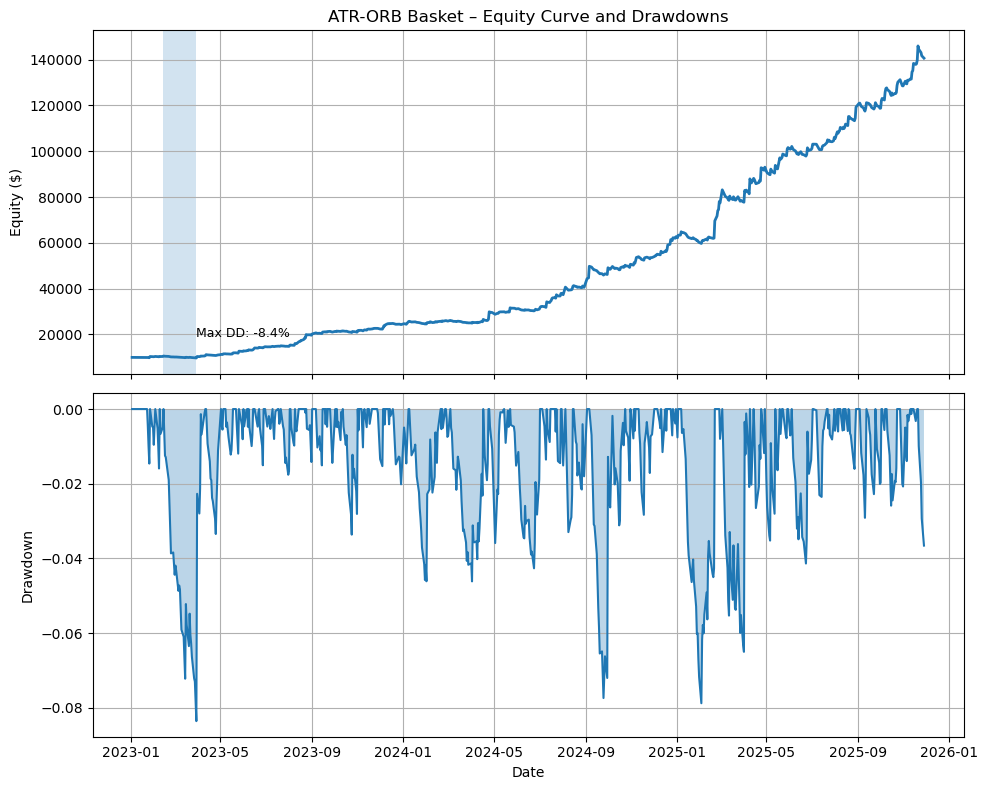

In [96]:
# === Drawdown summary + graph for ATR-ORB basket ===
equity = portfolio_equity_atr.copy().dropna()
equity.index = pd.to_datetime(equity.index)

# 1) Drawdown series
running_max = equity.cummax()
dd = equity / running_max - 1.0  # drawdown as fraction (<= 0)

# 2) Max drawdown
max_dd = dd.min()
max_dd_end = dd.idxmin()
max_dd_start = equity.loc[:max_dd_end].idxmax()

# Find recovery date: first date after max_dd_end when equity >= prior peak
prior_peak_val = equity.loc[max_dd_start]
post = equity.loc[max_dd_end:]
recovery_candidates = post[post >= prior_peak_val]
max_dd_recovery = recovery_candidates.index[0] if len(recovery_candidates) > 0 else None

# Length in calendar days
dd_len = (max_dd_end - max_dd_start).days if max_dd_start is not None else np.nan
recov_len = (
    (max_dd_recovery - max_dd_end).days
    if max_dd_recovery is not None else np.nan
)

print("=== ATR-ORB Basket – Max Drawdown Summary ===")
print(f"Max DD: {max_dd:.2%}")
print(f"From:   {max_dd_start.date()}  to  {max_dd_end.date()}")
print(f"DD length (peak → trough): {dd_len} calendar days")
if max_dd_recovery is not None:
    print(f"Recovered by: {max_dd_recovery.date()} "
          f"(trough → recovery: {recov_len} calendar days)")
else:
    print("No full recovery to prior peak yet in sample.")


# 3) Top-k drawdowns table (by depth)
def get_drawdown_table(equity_series, top=5, min_dd=-0.05):
    eq = equity_series.copy().dropna()
    run_max = eq.cummax()
    dd = eq / run_max - 1.0

    rows = []
    in_dd = False
    peak_date = None
    peak_val = None
    trough_date = None
    trough_val = None

    for date, val in eq.items():
        if peak_val is None or val >= peak_val:
            # new peak
            if peak_val is not None and trough_val is not None:
                dd_depth = trough_val / peak_val - 1.0
                if dd_depth <= min_dd:
                    rows.append({
                        "Peak Date": peak_date.date(),
                        "Trough Date": trough_date.date(),
                        "Depth %": dd_depth * 100,
                        "Length (days)": (trough_date - peak_date).days,
                    })
            peak_val = val
            peak_date = date
            trough_val = val
            trough_date = date
        else:
            # still in drawdown, maybe new trough
            if val < trough_val:
                trough_val = val
                trough_date = date

    dd_df = pd.DataFrame(rows)
    if not dd_df.empty:
        dd_df = dd_df.sort_values("Depth %").head(top)
    return dd_df

dd_top5 = get_drawdown_table(equity, top=5, min_dd=-0.02)

print("\n=== Top 5 Drawdowns (by depth) ===")
display(dd_top5.round(2))


# 4) Plot: Equity curve + Drawdown curve
fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# Equity curve
axes[0].plot(equity.index, equity.values, linewidth=2)
axes[0].set_ylabel("Equity ($)")
axes[0].set_title("ATR-ORB Basket – Equity Curve and Drawdowns")
axes[0].grid(True)

# Mark peak & trough of max DD
axes[0].axvspan(max_dd_start, max_dd_end, alpha=0.2)
axes[0].annotate(
    f"Max DD: {max_dd:.1%}",
    xy=(max_dd_end, equity.loc[max_dd_end]),
    xytext=(0, 15),
    textcoords="offset points",
    fontsize=9,
)

# Drawdown curve
axes[1].plot(dd.index, dd.values, linewidth=1.5)
axes[1].set_ylabel("Drawdown")
axes[1].set_xlabel("Date")
axes[1].grid(True)

# Fill area under drawdown
axes[1].fill_between(dd.index, dd.values, 0, alpha=0.3)

plt.tight_layout()
plt.show()

In [98]:
from scipy.stats import ttest_1samp
from statsmodels.stats.multitest import multipletests
import seaborn as sns


Summary Statistics:
------------------------------------------------------------
Total Strategies (stocks traded): 9
Sample period: 2023-01-03 → 2025-10-31
Average Risk-Free Rate: 5.04% (annualized)

Significant Strategies (H0: mean excess return = 0):
Raw (p < 0.05): 7
Bonferroni:        5
BH (FDR):          7
BY (FDR, dep.):    6

Correlation Statistics (ORB returns across stocks):
Average Pairwise Correlation: 0.192
Maximum Pairwise Correlation: 0.720

Top Strategies by Sharpe Ratio:
BULZ: Sharpe = 2.43, t-stat = 4.08, ann excess = 131.59%, Significant: Bonf, BH, BY
TSLL: Sharpe = 2.41, t-stat = 4.04, ann excess = 170.20%, Significant: Bonf, BH, BY
NVDL: Sharpe = 2.31, t-stat = 3.88, ann excess = 151.45%, Significant: Bonf, BH, BY
GGLL: Sharpe = 2.18, t-stat = 3.65, ann excess = 126.14%, Significant: Bonf, BH, BY
TECL: Sharpe = 1.76, t-stat = 2.96, ann excess = 91.49%, Significant: Bonf, BH, BY
TQQQ: Sharpe = 1.65, t-stat = 2.78, ann excess = 63.60%, Significant: BH, BY
URTY: Sharp

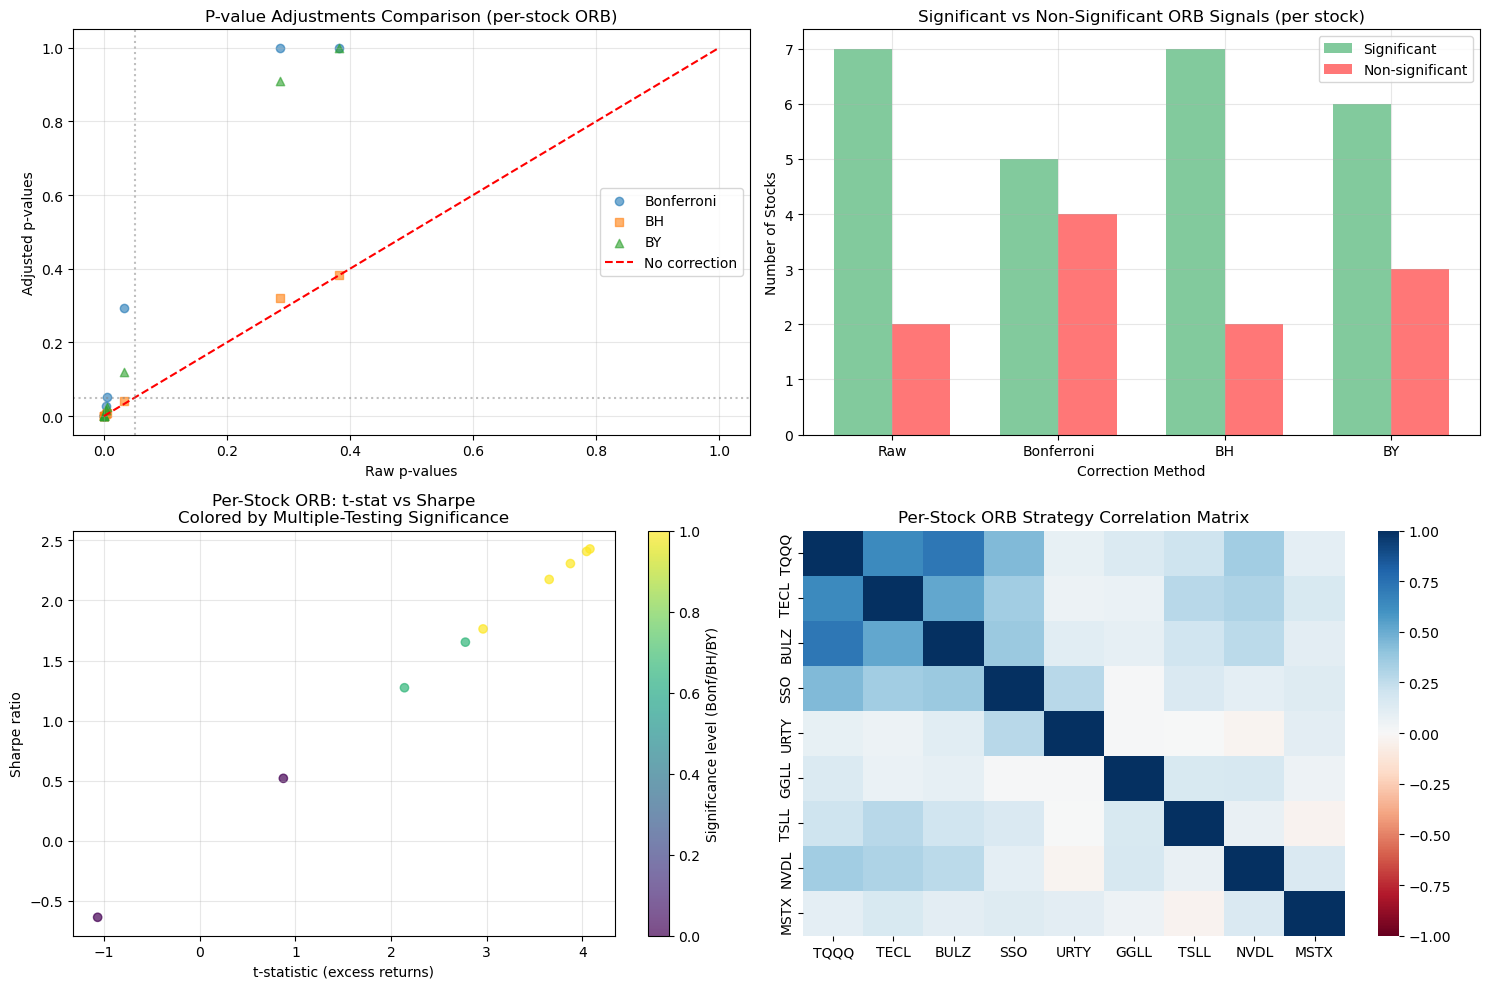

In [99]:
# ======================================================
# 0) INPUTS – adapt names if needed
# ------------------------------------------------------
# orb_rets_atr_df: DataFrame of daily ORB returns per stock (decimal)
# ff5: Fama–French 5-factor DataFrame with column "RF" (daily rf in decimal)

# Make sure indices are datetime and aligned
orb_rets = orb_rets_atr_df.copy()
orb_rets.index = pd.to_datetime(orb_rets.index)

rf_series = ff5["RF"].copy()
rf_series.index = pd.to_datetime(rf_series.index)

# Align on common dates
common_idx = orb_rets.index.intersection(rf_series.index)
orb_rets = orb_rets.loc[common_idx].sort_index()
rf_series = rf_series.loc[common_idx].sort_index()

# ======================================================
# 1) Helper: daily Sharpe with RF
# ------------------------------------------------------
def compute_sharpe_ratio_daily(returns, rf, periods_per_year=252):
    """
    Compute Sharpe ratio using daily returns and daily rf series.
    returns, rf: aligned Series of daily returns and daily risk-free (decimals).
    """
    excess_returns = returns - rf
    ann_excess_return = excess_returns.mean() * periods_per_year
    ann_vol = returns.std() * np.sqrt(periods_per_year)
    sharpe = ann_excess_return / ann_vol if ann_vol > 0 else 0.0
    return sharpe


# ======================================================
# 2) Compute stats for each traded stock
# ------------------------------------------------------
strategies = list(orb_rets.columns)  # each column = one ETF's ORB strategy
corr_matrix = orb_rets.corr()

strategy_stats = {}
for sym in strategies:
    rets = orb_rets[sym].dropna()
    if rets.empty:
        continue

    rf_matched = rf_series.loc[rets.index]

    excess_returns = rets - rf_matched

    # t-test on excess returns vs 0
    t_stat, p_val = ttest_1samp(excess_returns, 0.0, nan_policy="omit")

    # Sharpe on excess returns (daily)
    sharpe = compute_sharpe_ratio_daily(rets, rf_matched)

    strategy_stats[sym] = {
        "p_value": p_val,
        "t_stat": t_stat,
        "sharpe": sharpe,
    }

stats_df = pd.DataFrame(strategy_stats).T

# If for some reason no strategies, bail early
if stats_df.empty:
    print("No valid strategies found in orb_rets_atr_df.")
else:
    # ======================================================
    # 3) Multiple testing corrections: Bonferroni, BH, BY
    # ------------------------------------------------------
    p_values = stats_df["p_value"].values
    alpha = 0.05
    m = len(p_values)

    # Bonferroni
    bonf_threshold = alpha / m
    bonf_adjusted_p = np.minimum(p_values * m, 1.0)
    stats_df["bonf_adjusted_p"] = bonf_adjusted_p
    stats_df["bonf_significant"] = stats_df["p_value"] < bonf_threshold

    # BH (Benjamini–Hochberg)
    _, bh_adjusted_p, _, _ = multipletests(p_values, method="fdr_bh", alpha=alpha)
    stats_df["bh_adjusted_p"] = bh_adjusted_p
    stats_df["bh_significant"] = bh_adjusted_p < alpha

    # BY (Benjamini–Yekutieli)
    _, by_adjusted_p, _, _ = multipletests(p_values, method="fdr_by", alpha=alpha)
    stats_df["by_adjusted_p"] = by_adjusted_p
    stats_df["by_significant"] = by_adjusted_p < alpha

    # For convenience: also store raw annualized mean excess return
    daily_excess_mean = []
    for sym in stats_df.index:
        rets = orb_rets[sym].dropna()
        rf_m = rf_series.loc[rets.index]
        daily_excess_mean.append((rets - rf_m).mean())
    stats_df["mean_excess_daily"] = daily_excess_mean
    stats_df["mean_excess_annual"] = stats_df["mean_excess_daily"] * 252

    # ======================================================
    # 4) Summary printout
    # ------------------------------------------------------
    print("\nSummary Statistics:")
    print("-" * 60)
    print(f"Total Strategies (stocks traded): {len(stats_df)}")
    print(f"Sample period: {common_idx.min().date()} → {common_idx.max().date()}")
    print(f"Average Risk-Free Rate: {rf_series.mean() * 252:.2%} (annualized)")

    sig_raw = np.sum(stats_df["p_value"] < alpha)
    sig_bonf = np.sum(stats_df["bonf_significant"])
    sig_bh = np.sum(stats_df["bh_significant"])
    sig_by = np.sum(stats_df["by_significant"])

    print("\nSignificant Strategies (H0: mean excess return = 0):")
    print(f"Raw (p < {alpha}): {sig_raw}")
    print(f"Bonferroni:        {sig_bonf}")
    print(f"BH (FDR):          {sig_bh}")
    print(f"BY (FDR, dep.):    {sig_by}")

    # Correlation stats
    if len(corr_matrix) > 1:
        mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
        avg_corr = corr_matrix.values[mask].mean()
        max_corr = corr_matrix.values[mask].max()
    else:
        avg_corr = np.nan
        max_corr = np.nan

    print("\nCorrelation Statistics (ORB returns across stocks):")
    print(f"Average Pairwise Correlation: {avg_corr:.3f}")
    print(f"Maximum Pairwise Correlation: {max_corr:.3f}")

    print("\nTop Strategies by Sharpe Ratio:")
    top_strategies = stats_df.sort_values("sharpe", ascending=False).head(15)
    for idx, row in top_strategies.iterrows():
        sig_methods = []
        if row["bonf_significant"]:
            sig_methods.append("Bonf")
        if row["bh_significant"]:
            sig_methods.append("BH")
        if row["by_significant"]:
            sig_methods.append("BY")
        sig_str = ", ".join(sig_methods) if sig_methods else "None"
        print(
            f"{idx}: Sharpe = {row['sharpe']:.2f}, "
            f"t-stat = {row['t_stat']:.2f}, "
            f"ann excess = {row['mean_excess_annual']:.2%}, "
            f"Significant: {sig_str}"
        )

    # ======================================================
    # 5) Visualizations
    # ------------------------------------------------------
    fig = plt.figure(figsize=(15, 10))

    # (1) Raw vs adjusted p-values
    plt.subplot(2, 2, 1)
    plt.scatter(stats_df["p_value"], stats_df["bonf_adjusted_p"],
                alpha=0.6, label="Bonferroni", marker="o")
    plt.scatter(stats_df["p_value"], stats_df["bh_adjusted_p"],
                alpha=0.6, label="BH", marker="s")
    plt.scatter(stats_df["p_value"], stats_df["by_adjusted_p"],
                alpha=0.6, label="BY", marker="^")
    plt.plot([0, 1], [0, 1], "r--", label="No correction")
    plt.axhline(y=alpha, color="gray", linestyle=":", alpha=0.5)
    plt.axvline(x=alpha, color="gray", linestyle=":", alpha=0.5)
    plt.xlabel("Raw p-values")
    plt.ylabel("Adjusted p-values")
    plt.title("P-value Adjustments Comparison (per-stock ORB)")
    plt.legend()
    plt.grid(True, alpha=0.3)

    # (2) Significant vs non-significant counts
    plt.subplot(2, 2, 2)
    methods = ["Raw", "Bonferroni", "BH", "BY"]
    sig_counts = [sig_raw, sig_bonf, sig_bh, sig_by]
    non_sig_counts = [len(stats_df) - x for x in sig_counts]

    x = np.arange(len(methods))
    width = 0.35

    plt.bar(x - width/2, sig_counts, width, label="Significant", color="#82ca9d")
    plt.bar(x + width/2, non_sig_counts, width, label="Non-significant", color="#ff7777")
    plt.xlabel("Correction Method")
    plt.ylabel("Number of Stocks")
    plt.title("Significant vs Non-Significant ORB Signals (per stock)")
    plt.xticks(x, methods)
    plt.legend()
    plt.grid(True, alpha=0.3)

    # (3) T-stat vs Sharpe scatter colored by significance
    plt.subplot(2, 2, 3)
    colors = np.zeros(len(stats_df))
    colors[stats_df["bonf_significant"]] = 1
    colors[(~stats_df["bonf_significant"]) & stats_df["bh_significant"]] = 0.66
    colors[(~stats_df["bh_significant"]) & stats_df["by_significant"]] = 0.33

    scatter = plt.scatter(stats_df["t_stat"], stats_df["sharpe"],
                          c=colors, cmap="viridis", alpha=0.7)
    plt.colorbar(scatter, label="Significance level (Bonf/BH/BY)")
    plt.xlabel("t-statistic (excess returns)")
    plt.ylabel("Sharpe ratio")
    plt.title("Per-Stock ORB: t-stat vs Sharpe\nColored by Multiple-Testing Significance")
    plt.grid(True, alpha=0.3)

    # (4) Correlation heatmap of ORB strategies across stocks
    plt.subplot(2, 2, 4)
    sns.heatmap(
        corr_matrix,
        cmap="RdBu",
        center=0,
        vmin=-1,
        vmax=1,
        xticklabels=corr_matrix.columns,
        yticklabels=corr_matrix.columns,
    )
    plt.title("Per-Stock ORB Strategy Correlation Matrix")

    plt.tight_layout()
    plt.show()


In [104]:
def run_atr_orb_basket_period(
    symbols,
    daily_dict,
    intraday_dict,
    start_date,
    end_date,
    atr_frac=ATR_FRAC,
    risk_pct=RISK_PCT,
    max_leverage=MAX_LEVERAGE,
    slippage_bps=SLIPPAGE_BPS,
    start_capital=START_CAPITAL,
    commission_per_share=COMMISSION_PER_SHARE,
):
    """
    Run ATR-ORB strategy on a basket of symbols between [start_date, end_date].

    Handles tz-aware vs tz-naive indexes by internally converting to tz-naive.
    Returns:
        orb_rets_df: DataFrame of per-symbol daily returns
        portfolio_rets: Series of equal-weight portfolio returns
    """
    # Normalize start/end to tz-naive Timestamps
    start_date = pd.to_datetime(start_date)
    end_date   = pd.to_datetime(end_date)

    rets_dict = {}

    for sym in symbols:
        d_sym = daily_dict.get(sym)
        i_sym = intraday_dict.get(sym)

        if d_sym is None or i_sym is None:
            continue

        # --- Make daily index tz-naive (for ATR) ---
        d_local = d_sym.copy()
        if isinstance(d_local.index, pd.DatetimeIndex) and d_local.index.tz is not None:
            # convert to NY then strip tz
            d_local.index = d_local.index.tz_convert("America/New_York").tz_localize(None)

        # --- Make intraday index tz-naive (for date filtering) ---
        i_local = i_sym.copy()
        if isinstance(i_local.index, pd.DatetimeIndex) and i_local.index.tz is not None:
            i_local.index = i_local.index.tz_convert("America/New_York").tz_localize(None)

        # ---- Daily ATR up to end_date (ATR uses past data only) ----
        d_sub = d_local.loc[:end_date].copy()
        if d_sub.empty:
            continue

        atr14 = compute_atr14(d_sub)
        atr14_shifted = atr14.shift(1).dropna()  # use yesterday's ATR

        # ---- Intraday bars only within test window ----
        i_sub = i_local.loc[(i_local.index >= start_date) & (i_local.index <= end_date)].copy()
        if i_sub.empty:
            continue

        # Run your existing per-symbol backtest
        eq_sym, rets_sym = backtest_orb_5m_atr(
            i_sub,
            atr_series=atr14_shifted,
            atr_frac=atr_frac,
            slippage_bps=slippage_bps,
            start_capital=start_capital,
            risk_pct=risk_pct,
            max_leverage=max_leverage,
            commission_per_share=commission_per_share,
        )

        # Normalize index to date & clip to [start_date, end_date]
        rets_sym.index = pd.to_datetime(rets_sym.index).normalize()
        rets_sym = rets_sym.loc[(rets_sym.index >= start_date) & (rets_sym.index <= end_date)]

        if rets_sym.empty:
            continue

        rets_dict[sym] = rets_sym

    if not rets_dict:
        # No trades in this window
        return pd.DataFrame(), pd.Series(dtype=float)

    orb_rets_df = pd.DataFrame(rets_dict).sort_index().fillna(0.0)
    portfolio_rets = orb_rets_df.mean(axis=1)

    return orb_rets_df, portfolio_rets


In [105]:
def half_split_atr_orb_basket(
    symbols,
    daily_dict,
    intraday_dict,
    full_start,
    full_end,
    atr_grid=(0.03, 0.05, 0.07, 0.10),
):
    """
    Single half/half split:
      - Train on [full_start, mid_date]
      - Test  on (mid_date, full_end]
    Choose ATR_FRAC on training via Sharpe, then run OOS test.
    """
    full_start = pd.to_datetime(full_start)
    full_end   = pd.to_datetime(full_end)

    # midpoint in time between start and end
    mid_ts = full_start + (full_end - full_start) / 2
    mid_date = mid_ts.normalize()

    print(f"Full sample: {full_start.date()} → {full_end.date()}")
    print(f"Train:       {full_start.date()} → {mid_date.date()}")
    print(f"Test:        {(mid_date + pd.Timedelta(days=1)).date()} → {full_end.date()}")

    # ---------- 1) Optimize ATR_FRAC on training window ----------
    best_atr = None
    best_sharpe = -np.inf

    for atr_frac in atr_grid:
        _, train_portfolio_rets = run_atr_orb_basket_period(
            symbols,
            daily_dict,
            intraday_dict,
            start_date=full_start,
            end_date=mid_date,
            atr_frac=atr_frac,
        )

        if len(train_portfolio_rets) < 20:
            continue

        stats = perf_stats_from_rets(train_portfolio_rets)
        sharpe = stats.get("Sharpe", np.nan)
        print(f"  ATR_FRAC={atr_frac:.3f} → Train Sharpe={sharpe:.3f}")

        if not np.isnan(sharpe) and sharpe > best_sharpe:
            best_sharpe = sharpe
            best_atr = atr_frac

    if best_atr is None:
        print("No valid ATR_FRAC found in training half.")
        return None, None, {}, None

    print(f"\n>> Chosen ATR_FRAC={best_atr:.3f} (Train Sharpe={best_sharpe:.3f})")

    # ---------- 2) Run OOS test on second half ----------
    _, test_portfolio_rets = run_atr_orb_basket_period(
        symbols,
        daily_dict,
        intraday_dict,
        start_date=mid_date + pd.Timedelta(days=1),
        end_date=full_end,
        atr_frac=best_atr,
    )

    if test_portfolio_rets is None or test_portfolio_rets.empty:
        print("No OOS trades found in test half.")
        test_stats = {}
    else:
        test_stats = perf_stats_from_rets(test_portfolio_rets)

    return best_atr, test_portfolio_rets, test_stats, mid_date


Full sample: 2023-01-01 → 2025-10-30
Train:       2023-01-01 → 2024-05-31
Test:        2024-06-01 → 2025-10-30
  ATR_FRAC=0.030 → Train Sharpe=7.827
  ATR_FRAC=0.050 → Train Sharpe=5.801
  ATR_FRAC=0.070 → Train Sharpe=4.063
  ATR_FRAC=0.100 → Train Sharpe=2.340

>> Chosen ATR_FRAC=0.030 (Train Sharpe=7.827)

=== Half-Split OOS Stats (Second Half) ===
        CAGR: 2.3401
  Annual Vol: 0.2858
      Sharpe: 8.1869
       MaxDD: -0.0694
Total Return: 4.4419


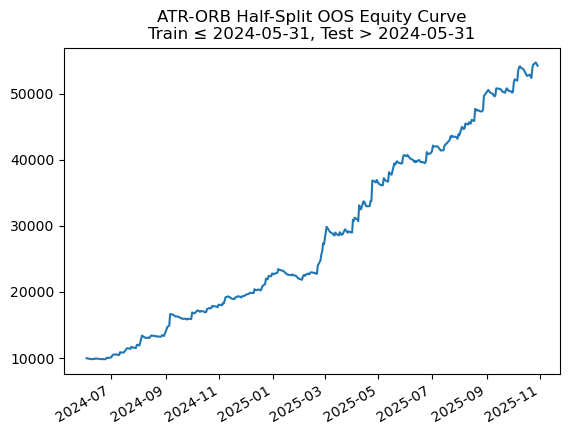

In [106]:
full_start = "2023-01-01"
full_end   = "2025-10-30"

symbols = my_etfs  # same basket

best_atr, test_rets_half, test_stats_half, split_date = half_split_atr_orb_basket(
    symbols=symbols,
    daily_dict=daily_dict,
    intraday_dict=intraday_dict,
    full_start=full_start,
    full_end=full_end,
    atr_grid=(0.03, 0.05, 0.07, 0.10),  # tweak as you like
)

print("\n=== Half-Split OOS Stats (Second Half) ===")
for k, v in (test_stats_half or {}).items():
    print(f"{k:>12}: {v:.4f}")

if test_rets_half is not None and not test_rets_half.empty:
    wf_equity_half = (1 + test_rets_half).cumprod() * START_CAPITAL
    wf_equity_half.plot(
        title=f"ATR-ORB Half-Split OOS Equity Curve\nTrain ≤ {split_date.date()}, Test > {split_date.date()}"
    )
